# Análise Exploratória de Dados de Proteômica

Este estudo fictício simula a análise de abundância proteica em amostras de sangue de adultos masculinos e femininos, coletadas **antes e depois da administração de um fármaco**.  
O objetivo é explorar como a intensidade proteica varia entre condições e entre sexos, utilizando técnicas básicas de análise exploratória de dados (EDA).


## Objetivos

- Explorar a distribuição das intensidades proteicas.
- Comparar abundância antes e depois do fármaco.
- Avaliar diferenças entre homens e mulheres.
- Investigar a interação entre sexo e condição.


In [3]:
import pandas as pd
import numpy as np

# Definir número de entradas
n = 7000

# Criar colunas
np.random.seed(42)  # para reprodutibilidade
proteins = [f"P{str(i).zfill(4)}" for i in np.random.randint(1, 2000, size=n)]
sample_ids = [f"S{str(i).zfill(4)}" for i in range(n)]
sex = np.random.choice(["Male", "Female"], size=n)
condition = np.random.choice(["BeforeDrug", "AfterDrug"], size=n)

# Intensidade simulada: valores maiores após o fármaco
intensity = []
for c in condition:
    if c == "BeforeDrug":
        intensity.append(np.random.normal(loc=50000, scale=10000))  # média menor
    else:
        intensity.append(np.random.normal(loc=70000, scale=12000))  # média maior

# Montar DataFrame
df = pd.DataFrame({
    "Protein": proteins,
    "SampleID": sample_ids,
    "Sex": sex,
    "Condition": condition,
    "Intensity": intensity
})

# Salvar em CSV
df.to_csv("proteomics_dataset.csv", index=False)

print("Dataset criado e salvo como proteomics_dataset.csv")
df.head()


Dataset criado e salvo como proteomics_dataset.csv


,Protein,SampleID,Sex,Condition,Intensity
0,P1127,S0000,Female,AfterDrug,65482.929345
1,P1460,S0001,Male,BeforeDrug,53160.678697
2,P0861,S0002,Male,BeforeDrug,55838.830223
3,P1295,S0003,Female,AfterDrug,85409.256342
4,P1131,S0004,Female,BeforeDrug,34927.741796


## Exploração inicial

Primeiro, verificamos a estrutura do dataset e as estatísticas descritivas.  
O dataset contém 7000 entradas, com colunas de identificação da proteína, amostra, sexo, condição experimental e intensidade.


In [4]:
# Carregar dataset
data = pd.read_csv("proteomics_dataset.csv")

# Primeiras linhas
print(data.head())

# Estatísticas descritivas
print(data.describe())

  Protein SampleID     Sex   Condition     Intensity
0   P1127    S0000  Female   AfterDrug  65482.929345
1   P1460    S0001    Male  BeforeDrug  53160.678697
2   P0861    S0002    Male  BeforeDrug  55838.830223
3   P1295    S0003  Female   AfterDrug  85409.256342
4   P1131    S0004  Female  BeforeDrug  34927.741796
           Intensity
count    7000.000000
mean    60025.119013
std     14690.736029
min     16788.854444
25%     49371.882401
50%     59037.060422
75%     70180.675115
max    109453.134249


## Distribuição de intensidades

O histograma abaixo mostra a distribuição geral das intensidades proteicas.  
Observamos que os valores seguem uma distribuição aproximadamente normal, com média maior nas amostras **após o fármaco**.


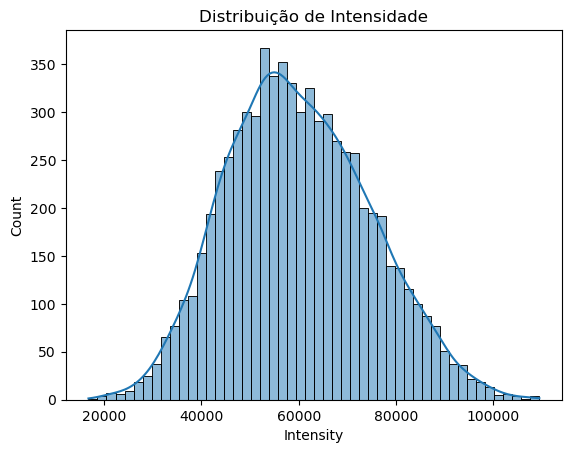

In [5]:
# Distribuição de intensidades
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data["Intensity"], bins=50, kde=True)
plt.title("Distribuição de Intensidade")
plt.show()

In [ ]:
## Comparação entre condições

O boxplot mostra que a intensidade proteica tende a ser maior **após o fármaco**, sugerindo um efeito de aumento na abundância proteica.


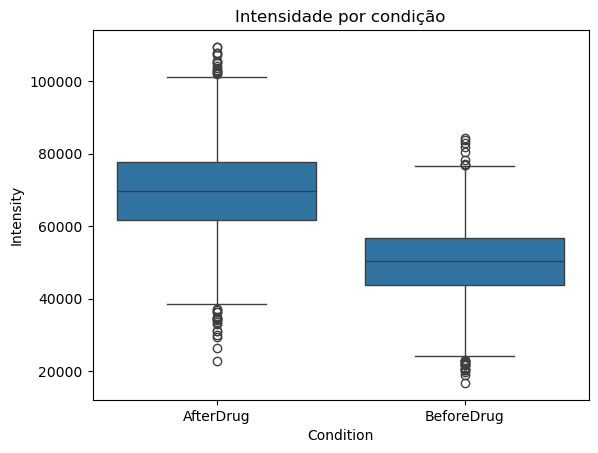

In [6]:
# Comparação antes vs depois do fármaco
sns.boxplot(x="Condition", y="Intensity", data=data)
plt.title("Intensidade por condição")
plt.show()

In [ ]:
## Interação sexo x condição

O gráfico abaixo mostra a distribuição de intensidades separada por sexo e condição.  
Podemos observar que o efeito do fármaco ocorre em ambos os sexos, mas com variações sutis.


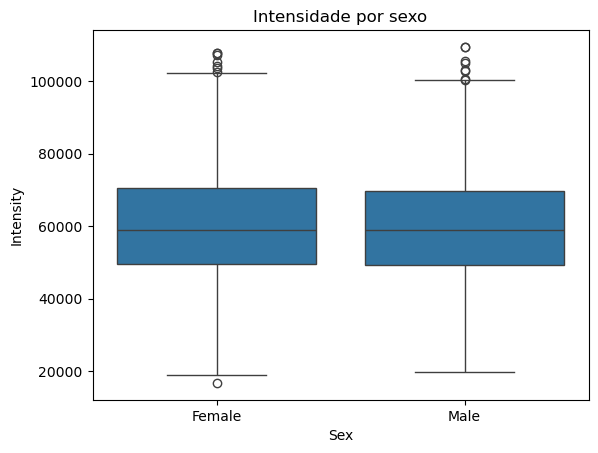

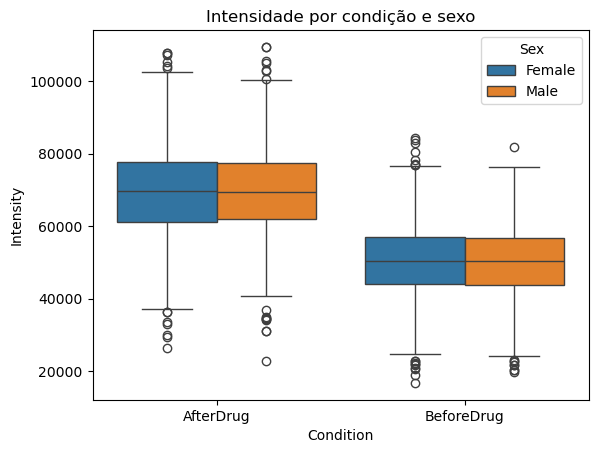

In [8]:
# Comparação por sexo
sns.boxplot(x="Sex", y="Intensity", data=data)
plt.title("Intensidade por sexo")
plt.show()
# Interação sexo x condição
sns.boxplot(x="Condition", y="Intensity", hue="Sex", data=data)
plt.title("Intensidade por condição e sexo")
plt.show()

## Conclusão

Este estudo fictício demonstra como técnicas simples de análise exploratória podem revelar padrões em dados de proteômica:

- O fármaco aumentou a intensidade proteica média.
- Homens e mulheres apresentam distribuições semelhantes, com pequenas diferenças.
- A interação entre sexo e condição sugere que o efeito do fármaco é consistente em ambos os grupos.

Este notebook serve como exemplo didático para portfólio, mostrando a aplicação de **Python, Pandas, Seaborn e Matplotlib** em análise de dados biomédicos.
